# Distributed Compressed Sensing (Multi-Machine Version)

This notebook studies the **wall-clock runtime** of distributed compressed sensing on heterogeneous devices, including **Raspberry Pi nodes** and commodity machines.

> A Ray cluster must be set up manually before running this notebook.

## Problem

We solve

$$
\min_{x \in \mathbb{R}^d}
\frac{1}{16}\sum_{i=1}^{16}\left(C_i \Psi x - y_i\right)^2
+ \lambda \|x\|_1 .
$$

Here, $C_i$ is the local measurement operator of worker $i$, $\Psi$ is the DCT basis, and $y_i$ is the local observation. The centralized optimal solution is denoted by $x^*$.

## Goal

We compare the runtime of **RAugDGM** under two communication schemes:

- **unquantized** (`float64`)
- **quantized** (`float64 → int16`)

The measured runtime includes the **entire execution**, including communication and quantization/dequantization overhead.

## Setup

The algorithm runs synchronously on **16 workers**:

- 8 Raspberry Pi nodes (1 process each)
- 1 desktop machine (4 processes)
- 1 laptop (4 processes)

Because the system is synchronous, total runtime is determined by the slowest workers.

## Experiment

- 500 iterations per run
- In each round:
  - one unquantized run
  - one quantized run
- Total wall-clock time is measured on the coordinator
- 20 rounds in total

Per-round runtimes are plotted to compare the two communication schemes.

## Network

The experiment uses a $4 \times 4$ grid network with gossip matrix

$$
W = I - 0.1L,
$$

where $L$ is the graph Laplacian.

In [9]:
import numpy as np
import numpy.typing as npt

from scipy.fftpack import dct

NUM_RUNS = 50
MAX_ITER = 100

import logging

logging.basicConfig(level=logging.INFO)

import networkx as nx

n_grid = 4
grid = nx.grid_2d_graph(n_grid, n_grid)
L: npt.NDArray[np.float64] = np.asarray(nx.laplacian_matrix(grid).todense())
W = np.eye(16) - L * 0.1

n_sens = W.shape[0]
sens_names = [f"{i + 1}" for i in range(n_sens)]

n = 4096
t = np.linspace(0, 1, n)
x = np.cos(2 * 97 * np.pi * t) + np.cos(2 * 777 * np.pi * t)

np.random.seed(3)
p_total = 128
p_sens = p_total // n_sens
perm = {i: np.round(np.random.rand(p_sens) * n).astype(int) for i in sens_names}
y = {i: x[perm[i]] for i in sens_names}

Psi = dct(np.eye(n), norm="ortho").astype(np.float64, copy=False)
Theta = {i: Psi[perm[i], :] for i in sens_names}
lam = 0.01

time_record: dict[str, list[float]] = {"quantized": [], "unquantized": []}

## Setup the cluster

In [13]:
import ray

ray.init(address="auto")

from jax import Array
from jax.numpy.linalg import norm

from conops.transform import Quantize, Identity


@ray.remote(num_cpus=1)
class Agent:
    def __init__(
        self,
        node_id: str,
        theta_i: npt.NDArray[np.float64],
        y_i: npt.NDArray[np.float64],
        dim_i: int,
        lam_i: float,
        max_iter: int,
    ) -> None:
        from conops import NodeHandle

        self.handle = NodeHandle(node_id, transport="tcp")

        self.theta_i = theta_i
        self.y_i = y_i
        self.dim_i = dim_i
        self.lam_i = lam_i
        self.max_iter = max_iter

        from dco import L1

        self.g = L1(self.lam_i)

    def f(self, var: npt.NDArray[np.float64]) -> Array:
        return norm(self.theta_i @ var - self.y_i) ** 2

    @ray.method
    def enable_quantization(self, quantize: bool) -> None:
        transform = Quantize("int16") if quantize else Identity()
        self.handle._transform = transform

    @ray.method
    def lasso(self) -> float:
        s_hat_i = np.zeros((self.max_iter, self.dim_i), dtype=np.float64)

        from dco import RAugDGM

        optimizer = RAugDGM(self.f, self.handle, 1.358, self.g)

        import time

        begin_time = time.time()

        optimizer.init(s_hat_i[0])

        for k in range(self.max_iter - 1):
            s_hat_i[k + 1] = optimizer.step(s_hat_i[k])

        end_time = time.time()

        return end_time - begin_time


from conops import Graph, bootstrap

graph = Graph.from_mixing_matrix(W, transport="tcp")
bootstrap(graph)
agents = [Agent.remote(i, Theta[i], y[i], n, lam, MAX_ITER) for i in sens_names]

2026-04-15 19:53:30,814	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 192.168.1.111:6379...
2026-04-15 19:53:30,847	INFO worker.py:2004 -- Connected to Ray cluster. View the dashboard at 127.0.0.1:8265 


INFO:conops.bootstrap:Graph 'default' running on: 192.168.1.112:46279
INFO:conops.discovery:Registered graph service with name 'default'
INFO:conops.bootstrap:Node '6' joined graph 'default' from 192.168.1.111:35697.
INFO:conops.bootstrap:Node '9' joined graph 'default' from 192.168.1.111:45319.
INFO:conops.bootstrap:Node '12' joined graph 'default' from 192.168.1.111:34651.
INFO:conops.bootstrap:Node '5' joined graph 'default' from 192.168.1.111:40701.
INFO:conops.bootstrap:Node '14' joined graph 'default' from 192.168.1.112:44651.
INFO:conops.bootstrap:Node '15' joined graph 'default' from 192.168.1.112:44787.
INFO:conops.bootstrap:Node '16' joined graph 'default' from 192.168.1.112:46551.
INFO:conops.bootstrap:Node '13' joined graph 'default' from 192.168.1.112:44891.
INFO:conops.bootstrap:Node '2' joined graph 'default' from 192.168.1.109:46677.
INFO:conops.bootstrap:Node '10' joined graph 'default' from 192.168.1.108:35085.
INFO:conops.bootstrap:Node '4' joined graph 'default' fro

### Unquantized

In [14]:
for agent in agents:
    ray.get(agent.enable_quantization.remote(False))

for run in range(NUM_RUNS):
    refs = [agent.lasso.remote() for agent in agents]
    worker_times = ray.get(refs)
    max_time = max(worker_times)
    time_record["unquantized"].append(max_time)

    print(f"Unquantized run time: {max_time:.4f} seconds at run {run}")

Unquantized run time: 20.7723 seconds at run 0
Unquantized run time: 19.3179 seconds at run 1
Unquantized run time: 21.4946 seconds at run 2
Unquantized run time: 20.9149 seconds at run 3
Unquantized run time: 21.2572 seconds at run 4
Unquantized run time: 21.6754 seconds at run 5
Unquantized run time: 20.6260 seconds at run 6
Unquantized run time: 20.7591 seconds at run 7
Unquantized run time: 19.9786 seconds at run 8
Unquantized run time: 21.2477 seconds at run 9
Unquantized run time: 20.3003 seconds at run 10
Unquantized run time: 21.4004 seconds at run 11
Unquantized run time: 19.4954 seconds at run 12
Unquantized run time: 20.7525 seconds at run 13
Unquantized run time: 20.6413 seconds at run 14
Unquantized run time: 20.9121 seconds at run 15
Unquantized run time: 21.5475 seconds at run 16
Unquantized run time: 19.3304 seconds at run 17
Unquantized run time: 22.7985 seconds at run 18
Unquantized run time: 17.3889 seconds at run 19
Unquantized run time: 18.9313 seconds at run 20
Un

### Quantized

In [16]:
for agent in agents:
    ray.get(agent.enable_quantization.remote(True))

for run in range(NUM_RUNS):
    refs = [agent.lasso.remote() for agent in agents]
    worker_times = ray.get(refs)
    max_time = max(worker_times)
    time_record["quantized"].append(max_time)

    print(f"Quantized run time: {max_time:.4f} seconds at run {run}")

Quantized run time: 8.3315 seconds at run 0
Quantized run time: 10.2320 seconds at run 1
Quantized run time: 8.0597 seconds at run 2
Quantized run time: 8.2748 seconds at run 3
Quantized run time: 8.5988 seconds at run 4
Quantized run time: 9.9891 seconds at run 5
Quantized run time: 7.1394 seconds at run 6
Quantized run time: 7.4194 seconds at run 7
Quantized run time: 7.0895 seconds at run 8
Quantized run time: 7.4049 seconds at run 9
Quantized run time: 9.3658 seconds at run 10
Quantized run time: 6.9361 seconds at run 11
Quantized run time: 6.7972 seconds at run 12
Quantized run time: 6.9393 seconds at run 13
Quantized run time: 7.0284 seconds at run 14
Quantized run time: 9.4225 seconds at run 15
Quantized run time: 7.1878 seconds at run 16
Quantized run time: 7.2739 seconds at run 17
Quantized run time: 7.2759 seconds at run 18
Quantized run time: 7.1340 seconds at run 19
Quantized run time: 9.2840 seconds at run 20
Quantized run time: 7.1431 seconds at run 21
Quantized run time:

In [18]:
ray.shutdown()

## Plot results

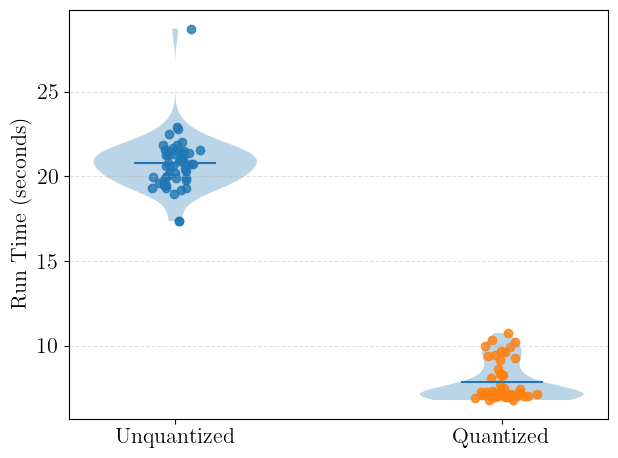

In [17]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = True  # 使用外部 LaTeX 编译器
plt.rcParams["font.family"] = "serif"  # 设置字体为 LaTeX 的默认 serif 字体

plt.rcParams.update(
    {
        "font.size": 14,  # 全局字体大小
        "axes.titlesize": 16,  # 坐标轴标题字体大小
        "axes.labelsize": 16,  # 坐标轴标签字体大小
        "xtick.labelsize": 16,  # x轴刻度标签字体大小
        "ytick.labelsize": 16,  # y轴刻度标签字体大小
        "legend.fontsize": 13,  # 图例字体大小
    }
)

u = time_record["unquantized"]
q = time_record["quantized"]

fig, ax = plt.subplots()

ax.violinplot([u, q], showmeans=True, showextrema=False)

x1 = np.random.normal(1, 0.04, size=len(u))
x2 = np.random.normal(2, 0.04, size=len(q))

ax.scatter(x1, u, alpha=0.8)
ax.scatter(x2, q, alpha=0.8)
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Unquantized", "Quantized"])
ax.set_ylabel("Run Time (seconds)")

fig.tight_layout()